In [34]:
from transformers import AutoTokenizer
import torch

# 加载Minimax 2.5 tokenizer
tokenizer = AutoTokenizer.from_pretrained("MiniMaxAI/MiniMax-M2.5")

In [38]:
print("Minimax M2.5词表大小:", tokenizer.vocab_size)

# 测试句子
text = "马嘉祺马嘉棋马嘉|祺马јект马嘉诚马佳琦马星驰"

# 编码
tokens = tokenizer(text, return_tensors="pt")
print("Token IDs:", tokens['input_ids'])

# 逐个解码Token ID
print("\n单个Token解码结果:")
for token_id in tokens['input_ids'][0]:
    decoded = tokenizer.decode([token_id])
    print(f"ID {token_id}: {decoded}")

# 完整解码
detokenized_text = tokenizer.decode(tokens['input_ids'][0])
print("\n完整解码结果:", detokenized_text)

Minimax M2.5词表大小: 200000
Token IDs: tensor([[  4143, 190467,   4143,  17050,  29789,   4143,  17050,    124,  95095,
           4143, 188214,   4143,  17050,  13043,   4143,  11041,  70519,   4143,
         177085]])

单个Token解码结果:
ID 4143: 马
ID 190467: 嘉祺
ID 4143: 马
ID 17050: 嘉
ID 29789: 棋
ID 4143: 马
ID 17050: 嘉
ID 124: |
ID 95095: 祺
ID 4143: 马
ID 188214: јект
ID 4143: 马
ID 17050: 嘉
ID 13043: 诚
ID 4143: 马
ID 11041: 佳
ID 70519: 琦
ID 4143: 马
ID 177085: 星驰

完整解码结果: 马嘉祺马嘉棋马嘉|祺马јект马嘉诚马佳琦马星驰


In [3]:
import json
vocab = json.load(open("/root/.cache/huggingface/hub/models--MiniMaxAI--MiniMax-M2.5/snapshots/f710177d938eff80b684d42c5aa84b382612f21f/vocab.json"))
reverse_vocab = {v: k for k, v in vocab.items()}
reverse_vocab[190467]

'åĺīç¥º'

In [7]:
# GPT-2 ByteLevel BPE mapping (bytes_to_unicode) + roundtrip demo
def bytes_to_unicode():
    bs = list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    cs = bs[:]
    n = 0
    for b in range(256):
        if b not in bs:
            bs.append(b)
            cs.append(256 + n)
            n += 1
    return dict(zip(bs, map(chr, cs)))

def unicode_to_bytes():
    btou = bytes_to_unicode()
    return {v: k for k, v in btou.items()}

# --- encode ---
text = "嘉祺"
utf8_bytes = text.encode("utf-8")  # e5 98 89 e7 a5 ba
btou = bytes_to_unicode()
encoded = "".join(btou[b] for b in utf8_bytes)

print("utf8 bytes hex:", utf8_bytes.hex(" "))
print("bytelevel encoded:", encoded)

# --- decode ---
utob = unicode_to_bytes()
decoded_bytes = bytes(utob[ch] for ch in encoded)
decoded_text = decoded_bytes.decode("utf-8")

print("decoded bytes hex:", decoded_bytes.hex(" "))
print("decoded text:", decoded_text)

utf8 bytes hex: e5 98 89 e7 a5 ba
bytelevel encoded: åĺīç¥º
decoded bytes hex: e5 98 89 e7 a5 ba
decoded text: 嘉祺


In [ ]:
from huggingface_hub import hf_hub_download
# 替换为实际模型名称，如 "MiniMaxAI/MiniMax-M1"
model_name = "MiniMaxAI/MiniMax-M2.5"
config_path = hf_hub_download(repo_id=model_name, filename="model.safetensors.index.json")
# "lm_head.weight": "model-00124-of-00126.safetensors"
# "model.embed_tokens.weight": "model-00000-of-00126.safetensors"
# 容器外运行 modelscope download --model MiniMax/MiniMax-M2.5 model-00124-of-00126.safetensors model-00000-of-00126.safetensors --local_dir ~/.cache/huggingface/hub/models--MiniMaxAI--MiniMax-M2.5/snapshots/f710177d938eff80b684d42c5aa84b382612f21f/

## lm_head 模长分析

In [ ]:
from safetensors import safe_open
weight_path_base = "/root/.cache/huggingface/hub/models--MiniMaxAI--MiniMax-M2.5/snapshots/f710177d938eff80b684d42c5aa84b382612f21f/"
# 用内存映射模式打开，不加载全量到内存
with safe_open(weight_path_base+"model-00124-of-00126.safetensors", framework="pt", device="cpu") as f:
    # 获取 lm_head 权重张量的形状
    lm_head = f.get_tensor("lm_head.weight")
    print(f"lm_head 形状: {lm_head.shape}")


lm_head 形状: torch.Size([200064, 3072])


In [28]:
import torch
# 计算 lm_head 200064 个行的 norm 并排序，然后打印前/后 10 的对应行数和模长，
lm_head_norms = lm_head.norm(dim=1)
sorted_norms, sorted_indices = torch.sort(lm_head_norms, descending=True)
print("前 10 行的 norm 排序:")
for i in range(10):
    print(f"行索引: {sorted_indices[i].item()}, 模长: {sorted_norms[i].item()}")
print("...")
print("后 10 行的 norm 排序:")
for i in range(1,11):
    print(f"行索引: {sorted_indices[-i].item()}, 模长: {sorted_norms[-i].item()}")
# 打印 lm_head 190467 行的模长，和排名
jq_rank = torch.where(sorted_indices == 190467)
jq_norm = sorted_norms[jq_rank]
print(f"lm_head 190467 行的模长: {jq_norm[0]}, 排名: {jq_rank[0][0]}")


前 10 行的 norm 排序:
行索引: 74541, 模长: 1.9296875
行索引: 93905, 模长: 1.8984375
行索引: 69635, 模长: 1.84375
行索引: 200034, 模长: 1.828125
行索引: 110712, 模长: 1.75
行索引: 88530, 模长: 1.7265625
行索引: 196954, 模长: 1.703125
行索引: 43013, 模长: 1.6875
行索引: 137081, 模长: 1.6875
行索引: 88628, 模长: 1.6796875
...
后 10 行的 norm 排序:
行索引: 121365, 模长: 0.455078125
行索引: 44259, 模长: 0.4765625
行索引: 63626, 模长: 0.484375
行索引: 76353, 模长: 0.490234375
行索引: 26502, 模长: 0.4921875
行索引: 18569, 模长: 0.4921875
行索引: 7168, 模长: 0.49609375
行索引: 23998, 模长: 0.498046875
行索引: 11357, 模长: 0.498046875
行索引: 51516, 模长: 0.5
lm_head 190467 行的模长: 1.0078125, 排名: 55266


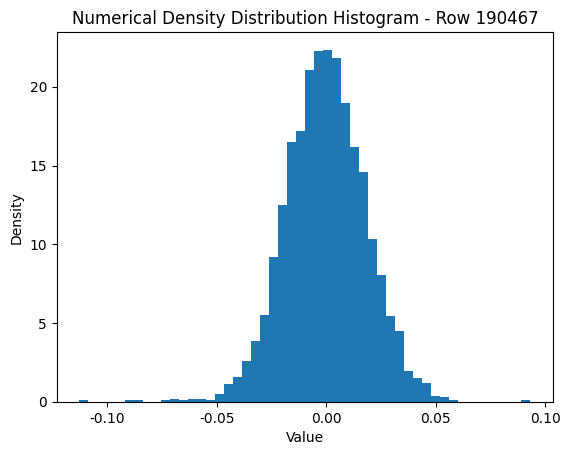

In [69]:
# 画出 190467 行向量的数值密度分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']  # 使用系统可用的无衬线字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 提取 190467 行向量的数值，BFloat16->Float16
vector_190467 = lm_head[190467].float().cpu().numpy()

# 绘制数值密度分布直方图
plt.hist(vector_190467, bins=50, density=True)
plt.title("Numerical Density Distribution Histogram - Row 190467")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

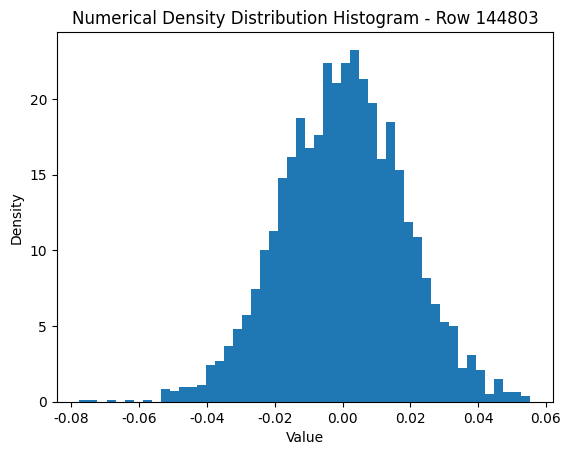

In [ ]:
# 画出 144803 行向量的数值密度分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']  # 使用系统可用的无衬线字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 提取 144803 行向量的数值，BFloat16->Float16
vector_144803 = lm_head[144803].float().cpu().numpy()

# 绘制数值密度分布直方图
plt.hist(vector_144803, bins=50, density=True)
plt.title("Numerical Density Distribution Histogram - Row 144803")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

In [ ]:
for i in (list(range(55260, 55271))):
    print(f"行索引: {sorted_indices[i].item()}, 模长: {sorted_norms[i].item()}，排名: {i}")

# 177085: 星驰
jq_rank_177085 = torch.where(sorted_indices == 177085)
jq_norm_177085 = sorted_norms[jq_rank_177085]
print(f"177085 行的模长: {jq_norm_177085[0]}, 排名: {jq_rank_177085[0][0]}")


行索引: 64389, 模长: 1.0078125，排名: 55260
行索引: 106211, 模长: 1.0078125，排名: 55261
行索引: 88961, 模长: 1.0078125，排名: 55262
行索引: 79755, 模长: 1.0078125，排名: 55263
行索引: 18722, 模长: 1.0078125，排名: 55264
行索引: 144803, 模长: 1.0078125，排名: 55265
行索引: 190467, 模长: 1.0078125，排名: 55266
行索引: 127123, 模长: 1.0078125，排名: 55267
行索引: 140509, 模长: 1.0078125，排名: 55268
行索引: 156037, 模长: 1.0078125，排名: 55269
行索引: 105931, 模长: 1.0078125，排名: 55270
177085 行的模长: 1.1015625, 排名: 19130


## embedding 相似度分析

In [31]:
from safetensors import safe_open
weight_path_base = "/root/.cache/huggingface/hub/models--MiniMaxAI--MiniMax-M2.5/snapshots/f710177d938eff80b684d42c5aa84b382612f21f/"
# 用内存映射模式打开，不加载全量到内存
with safe_open(weight_path_base+"model-00000-of-00126.safetensors", framework="pt", device="cpu") as f:
    # 获取 Embedding 权重张量的形状
    embedding = f.get_tensor("model.embed_tokens.weight")
    print(f"Embedding 形状: {embedding.shape}")


Embedding 形状: torch.Size([200064, 3072])


In [70]:
# 计算第 190467 行的向量与其它行向量的相似度，倒序排序，输出 top 10 的相似度和对应的行索引
import torch
# 提取第 190467 行的向量
target_vector = embedding[190467]
# 计算相似度
similarities = torch.cosine_similarity(embedding, target_vector.unsqueeze(0), dim=1)
# 倒序排序，获取 top 20 的索引
top_20_indices = similarities.argsort(descending=True)[:20]
# 输出 top 20 的相似度和对应的行索引
for i in top_20_indices:
    print(f"行索引: {i.item()}, 相似度: {similarities[i].item()}")  

# 输出 bottom 10 的相似度和对应的行索引
print("bottom 10:")
bottom_10_indices = similarities.argsort(descending=False)[:10]
for i in bottom_10_indices:
    print(f"行索引: {i.item()}, 相似度: {similarities[i].item()}")  

# 计算平均相似度
average_similarity = similarities.mean().item()
print(f"平均相似度: {average_similarity}")

# 找到 177085 行的相似度
similarity_177085 = similarities[177085].item()
print(f"177085 行的相似度: {similarity_177085}")


行索引: 190467, 相似度: 1.0
行索引: 183969, 相似度: 0.365234375
行索引: 198538, 相似度: 0.322265625
行索引: 95095, 相似度: 0.306640625
行索引: 198118, 相似度: 0.30078125
行索引: 17050, 相似度: 0.26953125
行索引: 197234, 相似度: 0.25390625
行索引: 183851, 相似度: 0.251953125
行索引: 56314, 相似度: 0.25
行索引: 73501, 相似度: 0.2421875
行索引: 96696, 相似度: 0.2412109375
行索引: 186194, 相似度: 0.240234375
行索引: 41302, 相似度: 0.236328125
行索引: 177085, 相似度: 0.232421875
行索引: 145898, 相似度: 0.2314453125
行索引: 181063, 相似度: 0.2265625
行索引: 22892, 相似度: 0.2255859375
行索引: 194743, 相似度: 0.2236328125
行索引: 196531, 相似度: 0.220703125
行索引: 187121, 相似度: 0.220703125
bottom 10:
行索引: 20106, 相似度: -0.1494140625
行索引: 13952, 相似度: -0.1474609375
行索引: 123957, 相似度: -0.1416015625
行索引: 26064, 相似度: -0.1396484375
行索引: 17783, 相似度: -0.1328125
行索引: 77149, 相似度: -0.1318359375
行索引: 43979, 相似度: -0.1298828125
行索引: 3382, 相似度: -0.12890625
行索引: 34321, 相似度: -0.12890625
行索引: 28522, 相似度: -0.125
平均相似度: 0.01373291015625
177085 行的相似度: 0.232421875


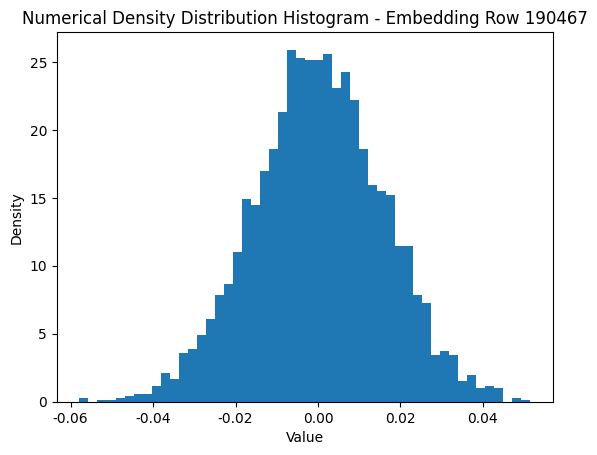

In [64]:
# 画出 190467 行向量的数值密度分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']  # 使用系统可用的无衬线字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 提取 190467 行向量的数值，BFloat16->Float16
emb_vector_190467 = embedding[196954].float().cpu().numpy()

# 绘制数值密度分布直方图
plt.hist(emb_vector_190467, bins=50, density=True)  
plt.title("Numerical Density Distribution Histogram - Embedding Row 190467")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

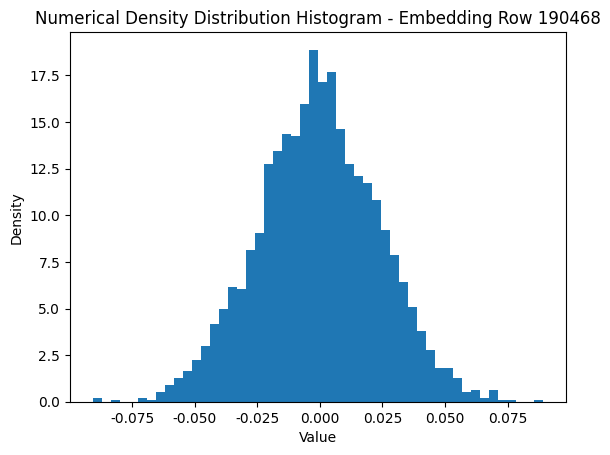

In [66]:
# 画出 190468 行向量的数值密度分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']  # 使用系统可用的无衬线字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 提取 190468 行向量的数值，BFloat16->Float16
emb_vector_190468 = embedding[190468].float().cpu().numpy()

# 绘制数值密度分布直方图
plt.hist(emb_vector_190468, bins=50, density=True)  
plt.title("Numerical Density Distribution Histogram - Embedding Row 190468")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

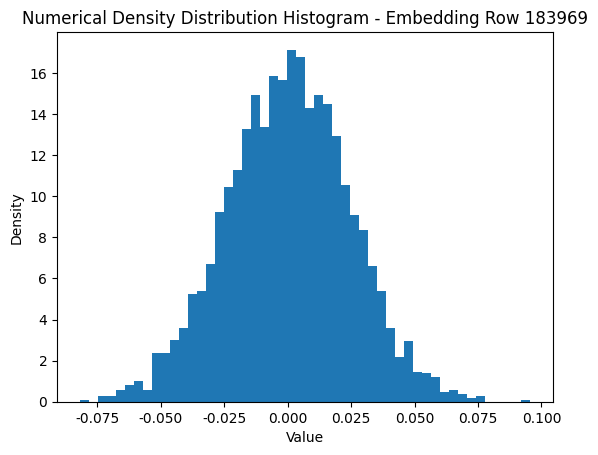

In [67]:
# 画出 183969 行向量的数值密度分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']  # 使用系统可用的无衬线字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 提取 183969 行向量的数值，BFloat16->Float16
emb_vector_183969 = embedding[183969].float().cpu().numpy()

# 绘制数值密度分布直方图
plt.hist(emb_vector_183969, bins=50, density=True)  
plt.title("Numerical Density Distribution Histogram - Embedding Row 183969")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

## embedding 和 lm_head 的行的相似性分析


In [61]:
# embedding 和 lm_head 的行的相似性
import torch

# 计算相似度
similarities = torch.cosine_similarity(embedding, lm_head, dim=1)

# 全局倒序排序
sorted_indices = similarities.argsort(descending=True)
sorted_similarities = similarities[sorted_indices]

# 输出 top 10 的索引和相似度
for i in range(10):
    print(f"行索引: {sorted_indices[i].item()}, 相似度: {sorted_similarities[i].item()}")

# 输出 bottom 10 的索引和相似度
for i in range(10):
    print(f"行索引: {sorted_indices[-i-1].item()}, 相似度: {sorted_similarities[-i-1].item()}")

# 输出第 190467 行的索引和相似度和排名
print("第 190467 行的相似性分析:")
print(f"行索引: {190467}, 相似度: {similarities[190467].item()}, 排名: {sorted_indices.tolist().index(190467)+1}")


行索引: 142520, 相似度: 0.0751953125
行索引: 150963, 相似度: 0.07421875
行索引: 198929, 相似度: 0.07421875
行索引: 97861, 相似度: 0.0732421875
行索引: 49334, 相似度: 0.0732421875
行索引: 109394, 相似度: 0.0732421875
行索引: 53979, 相似度: 0.072265625
行索引: 144714, 相似度: 0.072265625
行索引: 106099, 相似度: 0.0712890625
行索引: 100510, 相似度: 0.0703125
行索引: 20455, 相似度: -0.0888671875
行索引: 4096, 相似度: -0.0888671875
行索引: 29180, 相似度: -0.08251953125
行索引: 18274, 相似度: -0.08251953125
行索引: 1544, 相似度: -0.08251953125
行索引: 12643, 相似度: -0.08203125
行索引: 10206, 相似度: -0.08154296875
行索引: 15528, 相似度: -0.080078125
行索引: 101494, 相似度: -0.07958984375
行索引: 27686, 相似度: -0.07958984375
第 190467 行的相似性分析:
行索引: 190467, 相似度: -0.010009765625, 排名: 125210


In [63]:
# embedding 和 lm_head 的模长差异
import torch

# 计算模长
embedding_norms = torch.norm(embedding, dim=1)
lm_head_norms = torch.norm(lm_head, dim=1)

# 计算差异
norm_diffs = embedding_norms - lm_head_norms

# 全局排序
sorted_indices = norm_diffs.argsort(descending=True)
sorted_diffs = norm_diffs[sorted_indices]

# 输出 top 10 的索引和差异
for i in range(10):
    print(f"行索引: {sorted_indices[i].item()}, 差异: {sorted_diffs[i].item()}")

# 输出 bottom 10 的索引和差异
for i in range(10):
    print(f"行索引: {sorted_indices[-i-1].item()}, 差异: {sorted_diffs[-i-1].item()}")

# 输出第 190467 行的索引和差异和排名
print("第 190467 行的模长差异分析:")
print(f"行索引: {190467}, 差异: {norm_diffs[190467].item()}, 排名: {sorted_indices.tolist().index(190467)+1}, embedding 模长: {embedding_norms[190467].item()}, lm_head 模长: {lm_head_norms[190467].item()}")


行索引: 200021, 差异: 2.421875
行索引: 163627, 差异: 0.875
行索引: 200018, 差异: 0.84765625
行索引: 121365, 差异: 0.828125
行索引: 160030, 差异: 0.796875
行索引: 112077, 差异: 0.7890625
行索引: 200007, 差异: 0.78515625
行索引: 178461, 差异: 0.78125
行索引: 66020, 差异: 0.78125
行索引: 144665, 差异: 0.77734375
行索引: 254, 差异: -1.4921875
行索引: 253, 差异: -1.4921875
行索引: 193720, 差异: -1.4921875
行索引: 251, 差异: -1.4921875
行索引: 200055, 差异: -1.4921875
行索引: 200057, 差异: -1.4921875
行索引: 200059, 差异: -1.4921875
行索引: 245, 差异: -1.4921875
行索引: 193, 差异: -1.4921875
行索引: 200054, 差异: -1.4921875
第 190467 行的模长差异分析:
行索引: 190467, 差异: 0.3125, 排名: 145684, embedding 模长: 1.3203125, lm_head 模长: 1.0078125
